In [ ]:
import os
from ultralytics import YOLOWorld

# --- Configuration ---
# Choose a model size. 'l' (large) is generally more accurate for open-vocabulary tasks.
MODEL_NAME = 'yolov8l-world.pt' 
IMAGE_PATH = 'C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images' # <-- CHANGE THIS
CLASSES_FILE = 'lvis_classes.txt' 

# --- Function to load LVIS class names from file ---
def load_lvis_classes(filepath):
    """Reads a list of class names, one per line, from a file."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Classes file not found at: {filepath}")
    
    with open(filepath, 'r') as f:
        # Read lines, strip whitespace (like newline characters), and filter out empty lines
        class_list = [line.strip() for line in f if line.strip()]
        
    print(f"Loaded {len(class_list)} classes from {filepath}.")
    return class_list

# --- Main Detection Logic ---
try:
    # 1. Load the LVIS class names
    lvis_classes = load_lvis_classes(CLASSES_FILE)
    
    # 2. Initialize the YOLO-World model
    model = YOLOWorld(MODEL_NAME)
    print(f"Model {MODEL_NAME} loaded successfully.")
    
    # 3. Set the model's vocabulary to the LVIS classes
    # This is the key step for open-vocabulary detection.
    model.set_classes(lvis_classes)
    
    # 4. Run inference (Zero-Shot Detection)
    print(f"Starting zero-shot detection on: {IMAGE_PATH}")
    results = model.predict(
        source=IMAGE_PATH,
        conf=0.25, # Confidence threshold
        iou=0.7,   # IOU threshold
        save=True  # Save the output image with bounding boxes
    )
    
    # 5. Display results (optional)
    results[0].show()
    
    # Print the path where the annotated image was saved
    save_dir = os.path.join(os.getcwd(), results[0].save_dir)
    print(f"Results saved to: {save_dir}")

except Exception as e:
    print(f"An error occurred: {e}")

In [3]:
# pip install ultralytics

In [ ]:
import requests
import yaml
from ultralytics import YOLOWorld

# --- Configuration ---
# 1. Path to the LVIS YAML file on GitHub
LVIS_YAML_URL = 'https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/lvis.yaml'
# 2. Choose your YOLO-World model size
MODEL_NAME = 'yolov8l-world.pt' 
# 3. Path to the image you want to detect objects in
IMAGE_PATH = 'C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images'

CUSTOM_OUTPUT_PATH = r'C:\MastersRepos\LAION-5B Testing\LVIS_Detection_Results'
RUN_NAME = 'LVIS_Inference_Run'

# --- Step 1: Fetch and Parse LVIS Class Names from the YAML file ---
def get_lvis_classes_from_yaml(url):
    """Fetches the YAML file and returns the list of class names."""
    print(f"Fetching LVIS classes from: {url}")
    
    # Fetch the content of the YAML file
    response = requests.get(url)
    response.raise_for_status() # Check for request errors

    # Parse the YAML content
    lvis_data = yaml.safe_load(response.text)
    
    # The class names are stored under the 'names' key as a DICTIONARY {int: str}
    names_dict = lvis_data.get('names', {})
    
    if not names_dict:
        raise ValueError("Could not find 'names' key in the LVIS YAML data.")
        
    # FIX: Extract the values (class names) and sort them by the keys (class IDs)
    # The dictionary keys are 0, 1, 2, ...
    # We sort by the key and then get the corresponding value.
    class_list = [v for k, v in sorted(names_dict.items())] 
    
    print(f"Successfully loaded {len(class_list)} LVIS classes as a list.")
    # class_list is now a LIST OF STRINGS: ['aerosol can/spray can', 'air conditioner', ...]
    return class_list

# --- Step 2: Run YOLO-World Detection ---
# Get the 1203 LVIS class names
lvis_classes = get_lvis_classes_from_yaml(LVIS_YAML_URL)

# Initialize the YOLO-World model
model = YOLOWorld(MODEL_NAME)
print(f"Model {MODEL_NAME} loaded successfully.")

# Set the model's offline vocabulary to the full LVIS class list
model.set_classes(lvis_classes)

# Run zero-shot inference
print(f"Starting detection on: {IMAGE_PATH}")
results_generator = model.predict(
    source=IMAGE_PATH,
    conf=0.25, # Confidence threshold
    iou=0.7,   # IOU threshold
    save=True,  # Save the output image with bounding boxes
    stream=True,
    # 💥 New arguments to set the custom output folder 💥
    project=CUSTOM_OUTPUT_PATH,
    name=RUN_NAME,
    exist_ok=True  # Allows overwriting an existing folder named 'LVIS_Inference_Run'
)

# # Display the result and where it was saved
# results[0].show()
# print(f"Results saved to: {results[0].save_dir}")

# Iterate over the generator to trigger the processing
# This loop processes the batches one by one, saving the files as it goes.
# We no longer access results[0] because 'results' is now a generator.
# The iterator 'r' will contain the Results object for each image or batch.
last_result = None
file_count = 0
for r in results_generator:
    last_result = r
    # This print statement confirms that a batch was processed and saved
    print(f"Processed batch/image. Results saved to: {r.save_dir}")
    file_count += r.boxes.xyxy.shape[0] # Count detections in the batch

# Display the result and where it was saved
if last_result is not None:
    # Use last_result.path to show the path of the last image processed
    print(f"Successfully processed {file_count} detections across all images.") 
    print(f"Results saved in: {last_result.save_dir}")
    # Note: last_result.show() will try to display the *last* image processed.
else:
    print("No images were found at the specified source path or an error occurred.")

# Display the result and where it was saved
# Use the last processed result to show the output and directory info
if last_result is not None:
    last_result.show()
    print(f"Results saved to: {last_result.save_dir}")
else:
    print("No images were processed or no results were generated.")

Fetching LVIS classes from: https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/lvis.yaml
Successfully loaded 1203 LVIS classes as a list.
Model yolov8l-world.pt loaded successfully.
Starting detection on: C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images

image 1/10000 C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images\0.jpg: 480x640 1 streetlight/street lamp, 22.9ms
Processed batch/image. Results saved to: C:\MastersRepos\LAION-5B Testing\LVIS_Detection_Results\LVIS_Inference_Run
image 2/10000 C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images\10.jpg: 640x640 1 alcohol/alcoholic beverage, 3 bottles, 1 cupboard/closet, 33.3ms
Processed batch/image. Results saved to:

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x00000239167868C0>>
Traceback (most recent call last):
  File "c:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\.venv-Copy-Copy\lib\site-packages\ipykernel\ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


image 2735/10000 C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images\15836.jpg: 640x512 1 towel, 28.0ms
Processed batch/image. Results saved to: C:\MastersRepos\LAION-5B Testing\LVIS_Detection_Results\LVIS_Inference_Run
image 2736/10000 C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images\15841.jpg: 640x640 1 cat, 1 dog, 1 kitten/kitty, 1 painting, 1 puppy, 30.4ms
Processed batch/image. Results saved to: C:\MastersRepos\LAION-5B Testing\LVIS_Detection_Results\LVIS_Inference_Run
image 2737/10000 C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images\15842.jpg: 640x640 1 chopping board/cutting board/chopping block, 1 plate, 1 washbasin/basin/basin for washing/washbowl/washstand/handbasin, 30.1ms
Processed batch/

In [7]:
import requests
import yaml
from ultralytics import YOLOWorld

# --- Configuration ---
# ... (rest of your configuration remains the same)
LVIS_YAML_URL = 'https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/lvis.yaml'
MODEL_NAME = 'yolov8x-worldv2.pt' 
IMAGE_PATH = 'C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images'
CUSTOM_OUTPUT_PATH = r'C:\MastersRepos\LAION-5B Testing\LVIS_Detection_Results'
RUN_NAME = 'LVIS_Inference_Run_1280_3' # Changed run name to avoid conflicts

# --- Step 1 & 2: Initialization (same as before) ---
def get_lvis_classes_from_yaml(url):
    """Fetches the YAML file and returns the list of class names."""
    print(f"Fetching LVIS classes from: {url}")
    response = requests.get(url)
    response.raise_for_status() 
    lvis_data = yaml.safe_load(response.text)
    names_dict = lvis_data.get('names', {})
    if not names_dict:
        raise ValueError("Could not find 'names' key in the LVIS YAML data.")
    class_list = [v for k, v in sorted(names_dict.items())] 
    print(f"Successfully loaded {len(class_list)} LVIS classes as a list.")
    return class_list

lvis_classes = ['house']#get_lvis_classes_from_yaml(LVIS_YAML_URL)
model = YOLOWorld(MODEL_NAME)
print(f"Model {MODEL_NAME} loaded successfully.")
model.set_classes(lvis_classes)

# --- Step 3: Run YOLO-World Detection with Custom Image Size ---
print(f"Starting detection on: {IMAGE_PATH} with imgsz=1280")
results_generator = model.predict(
    source=IMAGE_PATH,
    # 💥 THE NEW ARGUMENT 💥
    imgsz=1280, 
    # Use 1280 for higher accuracy, or 1024 as a slightly faster compromise.
    
    conf=0.25, # Confidence threshold
    iou=0.7,   # IOU threshold
    save=True, # Save the output image with bounding boxes
    stream=True,
    project=CUSTOM_OUTPUT_PATH,
    name=RUN_NAME, # Note the updated run name
    exist_ok=True
)

# --- Step 4: Iterate over the generator (same as before) ---
last_result = None
file_count = 0
for r in results_generator:
    last_result = r
    print(f"Processed batch/image. Results saved to: {r.save_dir}")
    file_count += r.boxes.xyxy.shape[0]

if last_result is not None:
    print(f"Successfully processed {file_count} detections across all images.") 
    print(f"Results saved in: {last_result.save_dir}")
    # last_result.show() # Uncomment to display the last image
else:
    print("No images were found at the specified source path or an error occurred.")

Model yolov8x-worldv2.pt loaded successfully.
Starting detection on: C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images with imgsz=1280

image 1/10000 C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images\0.jpg: 928x1280 (no detections), 88.0ms
Processed batch/image. Results saved to: C:\MastersRepos\LAION-5B Testing\LVIS_Detection_Results\LVIS_Inference_Run_1280_3
image 2/10000 C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images\10.jpg: 1280x1280 (no detections), 119.1ms
Processed batch/image. Results saved to: C:\MastersRepos\LAION-5B Testing\LVIS_Detection_Results\LVIS_Inference_Run_1280_3
image 3/10000 C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\ImageCaptioningEvaluat

KeyboardInterrupt: 

In [3]:
# Instead of YOLOWorld, load a standard YOLOv8 model trained on COCO
from ultralytics import YOLO

# 1. Load a powerful YOLOv8 model (e.g., XL for best accuracy)
model = YOLO('yolov8x.pt') 
print(f"Model yolov8x.pt loaded successfully for high-accuracy detection.")

# 2. Define your class list based on COCO classes, focusing on subjects and context
# Example COCO class indices: person (0), car (2), dog (16), traffic light (9), handbag (26)
# If you only care about 'person' and key objects:
# target_indices = [0, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 26, 27] 
# This list is arbitrary, you must choose the COCO indices relevant to your bias study.

CUSTOM_OUTPUT_PATH = r'C:\MastersRepos\LAION-5B Testing\LVIS_Detection_Results'
RUN_NAME = 'YOLOv8x_Inference_Run'
IMAGE_PATH = 'C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images'

# Run standard high-accuracy inference
results_generator = model.predict(
    source=IMAGE_PATH,
    # Use a high-quality confidence threshold like 0.5 or 0.4
    conf=0.4, 
    # Use your custom class filter to limit the output to relevant categories
    # classes=target_indices, 
    iou=0.7, 
    save=True, 
    stream=True,
    project=CUSTOM_OUTPUT_PATH,
    name=RUN_NAME,
    exist_ok=True
)

# # Display the result and where it was saved
# results[0].show()
# print(f"Results saved to: {results[0].save_dir}")

# Iterate over the generator to trigger the processing
# This loop processes the batches one by one, saving the files as it goes.
# We no longer access results[0] because 'results' is now a generator.
# The iterator 'r' will contain the Results object for each image or batch.
last_result = None
file_count = 0
for r in results_generator:
    last_result = r
    # This print statement confirms that a batch was processed and saved
    print(f"Processed batch/image. Results saved to: {r.save_dir}")
    file_count += r.boxes.xyxy.shape[0] # Count detections in the batch

# Display the result and where it was saved
if last_result is not None:
    # Use last_result.path to show the path of the last image processed
    print(f"Successfully processed {file_count} detections across all images.") 
    print(f"Results saved in: {last_result.save_dir}")
    # Note: last_result.show() will try to display the *last* image processed.
else:
    print("No images were found at the specified source path or an error occurred.")

# Display the result and where it was saved
# Use the last processed result to show the output and directory info
if last_result is not None:
    last_result.show()
    print(f"Results saved to: {last_result.save_dir}")
else:
    print("No images were processed or no results were generated.")

Model yolov8x.pt loaded successfully for high-accuracy detection.

image 1/10000 C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images\0.jpg: 480x640 (no detections), 54.5ms
Processed batch/image. Results saved to: C:\MastersRepos\LAION-5B Testing\LVIS_Detection_Results\YOLOv8x_Inference_Run
image 2/10000 C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images\10.jpg: 640x640 2 bottles, 1 refrigerator, 35.7ms
Processed batch/image. Results saved to: C:\MastersRepos\LAION-5B Testing\LVIS_Detection_Results\YOLOv8x_Inference_Run
image 3/10000 C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images\1000.jpg: 480x640 1 person, 1 bottle, 26.6ms
Processed batch/image. Results saved to: C:\MastersRepos\LAION-5B Testing\LVIS

KeyboardInterrupt: 

Using device: cuda

Detected Objects:
  - Score: 0.7411, Box: [124, 79, 317, 174]
  - Score: 0.5678, Box: [43, 114, 185, 193]


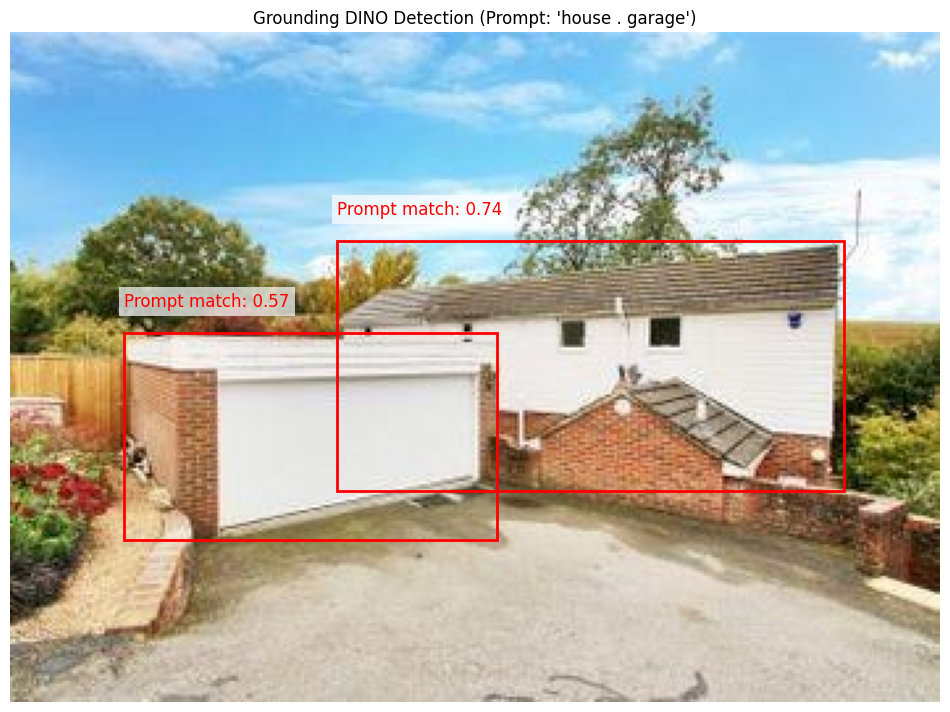

In [3]:
import torch
from PIL import Image
from transformers import AutoProcessor, GroundingDinoForObjectDetection
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# --- 1. Configuration ---
MODEL_ID = "IDEA-Research/grounding-dino-tiny"  # Or "IDEA-Research/grounding-dino-base"
IMAGE_PATH = r"C:\MastersRepos\LAION-5B Testing\LVIS_Detection_Results\LVIS_Inference_Run_1280_3\0.jpg" # Replace with your image path
TEXT_PROMPT = "house . garage" # The text prompt for detection
BOX_THRESHOLD = 0.25 # Threshold for filtering boxes based on confidence score

# Use CUDA if available, otherwise CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# --- 2. Load Model and Processor ---
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = GroundingDinoForObjectDetection.from_pretrained(MODEL_ID).to(device)

# --- 3. Load and Prepare Image and Text ---
try:
    image = Image.open(IMAGE_PATH).convert("RGB")
except FileNotFoundError:
    print(f"Error: Image file not found at {IMAGE_PATH}")
    exit()

def preprocess_caption(caption: str) -> str:
    """Grounding DINO was trained with a '.' after each text prompt."""
    result = caption.lower().strip()
    if result.endswith("."):
        return result
    return result + "."

# Prepare inputs for the model
inputs = processor(images=image, text=preprocess_caption(TEXT_PROMPT), return_tensors="pt").to(device)

# --- 4. Forward Pass (Inference) ---
with torch.no_grad():
    outputs = model(**inputs)

# --- 5. Post-processing and Visualization ---

# The model outputs normalized coordinates (0-1000 range, center_x, center_y, width, height)
# We need to post-process them to get actual pixel coordinates and filter by confidence.
target_sizes = torch.tensor([image.size[::-1]]).to(device)
results = processor.image_processor.post_process_object_detection(
    outputs,
    threshold=BOX_THRESHOLD,
    target_sizes=target_sizes
)[0]

# Setup for visualization
fig, ax = plt.subplots(1, figsize=(12, 9))
ax.imshow(image)

print("\nDetected Objects:")
for score, label_id, box in zip(results["scores"], results["labels"], results["boxes"]):
    # Convert box coordinates from [xmin, ymin, xmax, ymax] to integers
    box = [round(i, 2) for i in box.tolist()]
    
    # The label_id corresponds to the index in the input text prompt list (if there were multiple)
    # Since we only have one prompt, we can use the original text prompt for the label, 
    # but with multiple phrases/classes, a more complex mapping is needed.
    
    # For a simple single-phrase prompt, we'll just use the prompt as the label.
    # For proper multi-class labeling, you would need to use `processor.tokenizer.decode`
    # or handle the model's prediction of which phrase corresponds to the box.
    # In GroundingDINO, the 'logits' and 'phrases' are key for multi-phrase prompts.
    # Here, we'll use the prompt for simplicity, as GroundingDINO is designed 
    # for 'open-vocabulary' detection where the model 'grounds' the text.

    # Extract box components
    xmin, ymin, xmax, ymax = [int(i) for i in box]
    
    # Create a rectangle patch
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    
    # Add label and score text
    label_text = f"Prompt match: {score:.2f}" 
    ax.text(xmin, ymin - 10, label_text, color='red', fontsize=12,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    print(f"  - Score: {score:.4f}, Box: [{xmin}, {ymin}, {xmax}, {ymax}]")

ax.set_title(f"Grounding DINO Detection (Prompt: '{TEXT_PROMPT}')")
ax.axis('off')
plt.show()

Using device: cuda

Detected Objects:
  - Label: House, Score: 0.7411, Box: [124, 79, 317, 174]
  - Label: Garage, Score: 0.5678, Box: [43, 114, 185, 193]


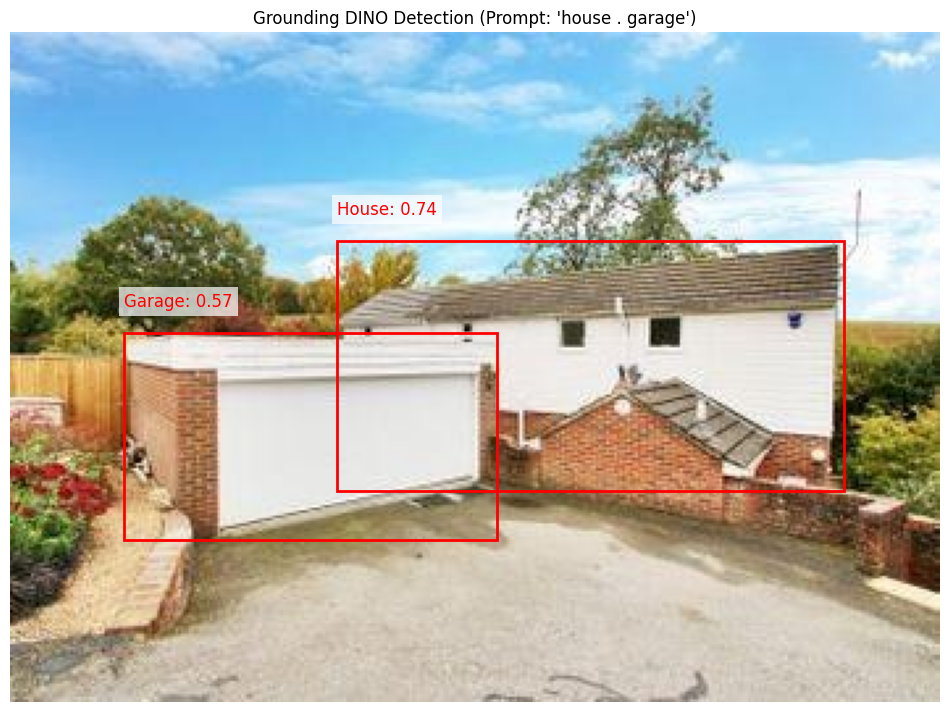

In [6]:
import torch
from PIL import Image
from transformers import AutoProcessor, GroundingDinoForObjectDetection
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# --- 1. Configuration ---
MODEL_ID = "IDEA-Research/grounding-dino-tiny"  # Or "IDEA-Research/grounding-dino-base"
# NOTE: The provided file path is a string literal, Python's raw string (r"...") is good for Windows paths.
IMAGE_PATH = r"C:\MastersRepos\LAION-5B Testing\LVIS_Detection_Results\LVIS_Inference_Run_1280_3\0.jpg" 
RAW_TEXT_PROMPT = "house . garage" # The text prompt for detection

# Split the prompt into individual phrases (labels)
# We clean up the list by removing periods and converting to a title case for display
TARGET_LABELS = [label.strip().strip('.') for label in RAW_TEXT_PROMPT.split('.')] 

BOX_THRESHOLD = 0.25 # Threshold for filtering boxes based on confidence score
TEXT_THRESHOLD = 0.25 # Threshold for filtering words in the text prompt

# Use CUDA if available, otherwise CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# --- 2. Load Model and Processor ---
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = GroundingDinoForObjectDetection.from_pretrained(MODEL_ID).to(device)

# --- 3. Load and Prepare Image and Text ---
try:
    image = Image.open(IMAGE_PATH).convert("RGB")
except FileNotFoundError:
    print(f"Error: Image file not found at {IMAGE_PATH}")
    exit()

def preprocess_caption(caption: str) -> str:
    """Grounding DINO was trained with a '.' after each text prompt."""
    result = caption.lower().strip()
    if result.endswith("."):
        return result
    return result + "."

# Prepare inputs for the model
# NOTE: The input text is the combined, preprocessed string
inputs = processor(images=image, 
                   text=preprocess_caption(RAW_TEXT_PROMPT), 
                   return_tensors="pt").to(device)

# --- 4. Forward Pass (Inference) ---
with torch.no_grad():
    outputs = model(**inputs)

# --- 5. Post-processing with Text Labels ---

# *** KEY CHANGE: Use the grounded post-processor ***
# This function is designed to link the detection box to the specific words in the prompt.
target_sizes = torch.tensor([image.size[::-1]]).to(device)
results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,  # Crucial: Pass the input token IDs for phrase grounding
    # box_threshold=BOX_THRESHOLD,
    # text_threshold=TEXT_THRESHOLD,
    threshold=TEXT_THRESHOLD,
    target_sizes=target_sizes
)[0]

# Setup for visualization
fig, ax = plt.subplots(1, figsize=(12, 9))
ax.imshow(image)

print("\nDetected Objects:")
# The results dictionary now contains a 'text_labels' key with the actual phrases!
for score, label_text, box in zip(results["scores"], results["text_labels"], results["boxes"]):
    # Convert box coordinates from [xmin, ymin, xmax, ymax] to integers
    box = [round(i, 2) for i in box.tolist()]
    
    # Extract box components
    xmin, ymin, xmax, ymax = [int(i) for i in box]
    
    # Create a rectangle patch
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    
    # Add the actual text label and score
    label_text_display = f"{label_text.title()}: {score:.2f}"
    ax.text(xmin, ymin - 10, label_text_display, color='red', fontsize=12,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    print(f"  - Label: {label_text.title()}, Score: {score:.4f}, Box: [{xmin}, {ymin}, {xmax}, {ymax}]")

ax.set_title(f"Grounding DINO Detection (Prompt: '{RAW_TEXT_PROMPT}')")
ax.axis('off')
plt.show()

# The specific video linked shows how to combine Grounding DINO with the Segment Anything Model (SAM) for automated image annotation, which is a common and advanced use case after successfully getting object detections. [Accelerate Image Annotation with SAM and Grounding DINO](https://www.youtube.com/watch?v=oEQYStnF2l8)


# http://googleusercontent.com/youtube_content/3

In [11]:
import torch
from PIL import Image
from transformers import AutoProcessor, GroundingDinoForObjectDetection
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import requests
import yaml

# --- 1. Configuration (Example LVIS URL for completeness) ---
MODEL_ID = "IDEA-Research/grounding-dino-tiny"
IMAGE_PATH = r"C:\MastersRepos\LAION-5B Testing\LVIS_Detection_Results\LVIS_Inference_Run_1280_3\0.jpg" 
LVIS_YAML_URL = 'https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/lvis.yaml'

BOX_THRESHOLD = 0.25
TEXT_THRESHOLD = 0.25 

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


# --- Step 1 & 2: Initialization (same as before) ---
def get_lvis_classes_from_yaml(url):
    """Fetches the YAML file and returns the list of class names."""
    print(f"Fetching LVIS classes from: {url}")
    response = requests.get(url)
    response.raise_for_status() 
    lvis_data = yaml.safe_load(response.text)
    names_dict = lvis_data.get('names', {})
    if not names_dict:
        raise ValueError("Could not find 'names' key in the LVIS YAML data.")
    class_list = [v for k, v in sorted(names_dict.items())] 
    print(f"Successfully loaded {len(class_list)} LVIS classes as a list.")
    return class_list

def structure_labels_for_grounding_dino(labels: list) -> str:
    """
    Takes a list of class labels and formats it into the required 
    Grounding DINO text prompt format: "label1 . label2 . label3 ."
    """
    # 1. Clean labels (ensure no leading/trailing spaces or existing dots)
    cleaned_labels = [label.strip().strip('.').lower() for label in labels]
    
    # 2. Join the labels with " . " 
    prompt = " . ".join(cleaned_labels)
    
    # 3. Ensure the prompt ends with a period, as required by GDINO
    if not prompt.endswith('.'):
        prompt += "."
    
    return prompt

# Example Usage with a simplified list:
class_list = get_lvis_classes_from_yaml(LVIS_YAML_URL)
print(f"First 10 LVIS Classes: {class_list[:10]}")

RAW_TEXT_PROMPT = structure_labels_for_grounding_dino(class_list)

print(f"\nOriginal List: {class_list}")
print(f"GDINO Prompt: {RAW_TEXT_PROMPT}")

TARGET_LABELS = [label.strip().strip('.') for label in RAW_TEXT_PROMPT.split('.')] 

BOX_THRESHOLD = 0.25 # Threshold for filtering boxes based on confidence score
TEXT_THRESHOLD = 0.25 # Threshold for filtering words in the text prompt

# Use CUDA if available, otherwise CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# --- 2. Load Model and Processor ---
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = GroundingDinoForObjectDetection.from_pretrained(MODEL_ID).to(device)

# --- 3. Load and Prepare Image and Text ---
try:
    image = Image.open(IMAGE_PATH).convert("RGB")
except FileNotFoundError:
    print(f"Error: Image file not found at {IMAGE_PATH}")
    exit()

def preprocess_caption(caption: str) -> str:
    """Grounding DINO was trained with a '.' after each text prompt."""
    result = caption.lower().strip()
    if result.endswith("."):
        return result
    return result + "."

# Prepare inputs for the model
# NOTE: The input text is the combined, preprocessed string
inputs = processor(images=image, 
                   text=preprocess_caption(RAW_TEXT_PROMPT), 
                   return_tensors="pt").to(device)

# --- 4. Forward Pass (Inference) ---
with torch.no_grad():
    outputs = model(**inputs)

# --- 5. Post-processing with Text Labels ---

# *** KEY CHANGE: Use the grounded post-processor ***
# This function is designed to link the detection box to the specific words in the prompt.
target_sizes = torch.tensor([image.size[::-1]]).to(device)
results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,  # Crucial: Pass the input token IDs for phrase grounding
    # box_threshold=BOX_THRESHOLD,
    # text_threshold=TEXT_THRESHOLD,
    threshold=TEXT_THRESHOLD,
    target_sizes=target_sizes
)[0]

# Setup for visualization
fig, ax = plt.subplots(1, figsize=(12, 9))
ax.imshow(image)

print("\nDetected Objects:")
# The results dictionary now contains a 'text_labels' key with the actual phrases!
for score, label_text, box in zip(results["scores"], results["text_labels"], results["boxes"]):
    # Convert box coordinates from [xmin, ymin, xmax, ymax] to integers
    box = [round(i, 2) for i in box.tolist()]
    
    # Extract box components
    xmin, ymin, xmax, ymax = [int(i) for i in box]
    
    # Create a rectangle patch
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    
    # Add the actual text label and score
    label_text_display = f"{label_text.title()}: {score:.2f}"
    ax.text(xmin, ymin - 10, label_text_display, color='red', fontsize=12,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    print(f"  - Label: {label_text.title()}, Score: {score:.4f}, Box: [{xmin}, {ymin}, {xmax}, {ymax}]")

ax.set_title(f"Grounding DINO Detection (Prompt: '{RAW_TEXT_PROMPT}')")
ax.axis('off')
plt.show()

Using device: cuda
Fetching LVIS classes from: https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/lvis.yaml
Successfully loaded 1203 LVIS classes as a list.
First 10 LVIS Classes: ['aerosol can/spray can', 'air conditioner', 'airplane/aeroplane', 'alarm clock', 'alcohol/alcoholic beverage', 'alligator/gator', 'almond', 'ambulance', 'amplifier', 'anklet/ankle bracelet']

Original List: ['aerosol can/spray can', 'air conditioner', 'airplane/aeroplane', 'alarm clock', 'alcohol/alcoholic beverage', 'alligator/gator', 'almond', 'ambulance', 'amplifier', 'anklet/ankle bracelet', 'antenna/aerial/transmitting aerial', 'apple', 'applesauce', 'apricot', 'apron', 'aquarium/fish tank', 'arctic/arctic type of shoe/galosh/golosh/rubber/rubber type of shoe/gumshoe', 'armband', 'armchair', 'armoire', 'armor/armour', 'artichoke', 'trash can/garbage can/wastebin/dustbin/trash barrel/trash bin', 'ashtray', 'asparagus', 'atomizer/atomiser/spray/sprayer/nebulizer/nebuli

Token indices sequence length is longer than the specified maximum sequence length for this model (6049 > 512). Running this sequence through the model will result in indexing errors


RuntimeError: The size of tensor a (6049) must match the size of tensor b (256) at non-singleton dimension 2

Using device: cuda
Fetching LVIS classes from: https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/lvis.yaml
Successfully loaded 1203 LVIS classes as a list.
Full LVIS class count: 1203
Processing in 41 chunks of max 30 classes...

--- Chunk 1/41 (30 classes) ---

--- Chunk 2/41 (30 classes) ---

--- Chunk 3/41 (30 classes) ---

--- Chunk 4/41 (30 classes) ---

--- Chunk 5/41 (30 classes) ---

--- Chunk 6/41 (30 classes) ---

--- Chunk 7/41 (30 classes) ---

--- Chunk 8/41 (30 classes) ---

--- Chunk 9/41 (30 classes) ---

--- Chunk 10/41 (30 classes) ---

--- Chunk 11/41 (30 classes) ---

--- Chunk 12/41 (30 classes) ---

--- Chunk 13/41 (30 classes) ---

--- Chunk 14/41 (30 classes) ---

--- Chunk 15/41 (30 classes) ---

--- Chunk 16/41 (30 classes) ---

--- Chunk 17/41 (30 classes) ---

--- Chunk 18/41 (30 classes) ---

--- Chunk 19/41 (30 classes) ---

--- Chunk 20/41 (30 classes) ---

--- Chunk 21/41 (30 classes) ---

--- Chunk 22/41 (30 classes

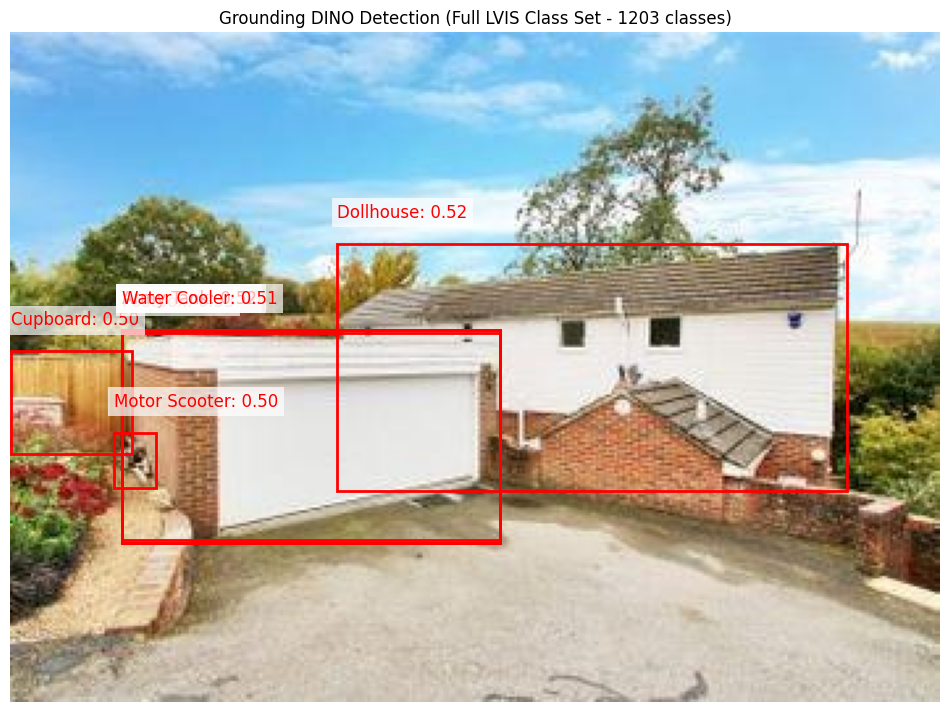

In [10]:
import torch
from PIL import Image
from transformers import AutoProcessor, GroundingDinoForObjectDetection
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import requests
import yaml
from typing import List, Dict, Any

# --- 1. Configuration ---
MODEL_ID = "IDEA-Research/grounding-dino-tiny"
# Assuming '10018.jpg' is the file you want to use for the image
IMAGE_PATH = r"C:\MastersRepos\LAION-5B Testing\LVIS_Detection_Results\LVIS_Inference_Run_1280_3\0.jpg"
LVIS_YAML_URL = 'https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/lvis.yaml'

# Maximum number of classes to process in a single Grounding DINO forward pass.
# This limit is critical to avoid the RuntimeError due to token limit overflow.
# A safe number is 60-80, as the classes are often multi-word.
MAX_CLASSES_PER_CHUNK = 30 

BOX_THRESHOLD = 0.25 
TEXT_THRESHOLD = 0.5 

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# --- Helper Functions (Unchanged) ---
def get_lvis_classes_from_yaml(url):
    """Fetches the YAML file and returns the list of class names."""
    print(f"Fetching LVIS classes from: {url}")
    response = requests.get(url)
    response.raise_for_status() 
    lvis_data = yaml.safe_load(response.text)
    names_dict = lvis_data.get('names', {})
    if not names_dict:
        raise ValueError("Could not find 'names' key in the LVIS YAML data.")
    class_list = [v for k, v in sorted(names_dict.items())] 
    new_list = [item.split('/')[0] for item in class_list]
    print(f"Successfully loaded {len(class_list)} LVIS classes as a list.")
    return new_list

def structure_labels_for_grounding_dino(labels: list) -> str:
    """
    Takes a list of class labels and formats it into the required 
    Grounding DINO text prompt format: "label1 . label2 . label3 ."
    """
    cleaned_labels = [label.strip().strip('.').lower() for label in labels]
    prompt = " . ".join(cleaned_labels)
    if not prompt.endswith('.'):
        prompt += "."
    return prompt

# --- 2. Load Model and Processor ---
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = GroundingDinoForObjectDetection.from_pretrained(MODEL_ID).to(device)

# --- 3. Load Image and LVIS Classes ---
try:
    # Use the uploaded image file (or the placeholder path if you change it)
    image = Image.open(IMAGE_PATH).convert("RGB") 
except FileNotFoundError:
    print(f"Error: Image file not found at {IMAGE_PATH}")
    exit()

# Get the full list of classes
full_class_list = get_lvis_classes_from_yaml(LVIS_YAML_URL)
print(f"Full LVIS class count: {len(full_class_list)}")

# --- 4. BATCH INFERENCE LOGIC (The Core Change) ---
all_detections: List[Dict[str, Any]] = []
num_classes = len(full_class_list)
num_chunks = (num_classes + MAX_CLASSES_PER_CHUNK - 1) // MAX_CLASSES_PER_CHUNK # Ceiling division

print(f"Processing in {num_chunks} chunks of max {MAX_CLASSES_PER_CHUNK} classes...")

for i in range(num_chunks):
    start_idx = i * MAX_CLASSES_PER_CHUNK
    end_idx = min((i + 1) * MAX_CLASSES_PER_CHUNK, num_classes)
    
    # 1. Get the class subset for this chunk
    class_chunk = full_class_list[start_idx:end_idx]
    
    # 2. Format the prompt for this chunk
    chunk_prompt = structure_labels_for_grounding_dino(class_chunk)
    
    print(f"\n--- Chunk {i+1}/{num_chunks} ({len(class_chunk)} classes) ---")
    
    # 3. Prepare inputs for this chunk
    inputs = processor(images=image, 
                       text=chunk_prompt, 
                       return_tensors="pt").to(device)

    # 4. Forward Pass (Inference)
    with torch.no_grad():
        outputs = model(**inputs)

    # 5. Post-processing with Text Labels
    target_sizes = torch.tensor([image.size[::-1]]).to(device)
    
    # FIX: Use single 'threshold' argument to avoid TypeError
    chunk_results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,  # Pass the token IDs for phrase grounding
        threshold=TEXT_THRESHOLD,
        target_sizes=target_sizes
    )[0]
    
    # 6. Accumulate results
    if len(chunk_results["scores"]) > 0:
        for score, label_text, box in zip(chunk_results["scores"], 
                                           chunk_results["text_labels"], 
                                           chunk_results["boxes"]):
            all_detections.append({
                "score": score.item(),
                "label": label_text.title(),
                "box": [int(round(i.item())) for i in box]
            })

print(f"\n--- Batch Processing Complete. Total Detections: {len(all_detections)} ---")

# --- 5. Visualization ---

fig, ax = plt.subplots(1, figsize=(12, 9))
ax.imshow(image)

print("\nDetected Objects (Summary):")
for det in all_detections:
    score = det["score"]
    label_text = det["label"]
    xmin, ymin, xmax, ymax = det["box"]
    
    # Create a rectangle patch
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    
    # Add the actual text label and score
    label_text_display = f"{label_text}: {score:.2f}"
    ax.text(xmin, ymin - 10, label_text_display, color='red', fontsize=12,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    print(f"  - Label: {label_text}, Score: {score:.4f}, Box: [{xmin}, {ymin}, {xmax}, {ymax}]")

ax.set_title(f"Grounding DINO Detection (Full LVIS Class Set - {len(full_class_list)} classes)")
ax.axis('off')
plt.show()

In [ ]:
import torch
from PIL import Image
from transformers import AutoProcessor, GroundingDinoForObjectDetection
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import requests
import yaml
import glob
import os
from typing import List, Dict, Any

# ==========================================================
# 1. CONFIGURATION
# ==========================================================
MODEL_ID = "IDEA-Research/grounding-dino-tiny"
IMAGE_DIR = r"C:\MastersRepos\LAION-5B Testing\LVIS_Detection_Results\LVIS_Inference_Run_1280_3"
LVIS_YAML_URL = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/lvis.yaml"

MAX_CLASSES_PER_CHUNK = 10   # number of classes per text chunk (avoid token overflow)
MAX_IMAGES_PER_BATCH = 4     # adjust for GPU memory
BOX_THRESHOLD = 0.25
TEXT_THRESHOLD = 0.5

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# ==========================================================
# 2. HELPER FUNCTIONS
# ==========================================================
def get_lvis_classes_from_yaml(url: str) -> List[str]:
    """Fetch the LVIS YAML and extract class names."""
    print(f"Fetching LVIS classes from: {url}")
    response = requests.get(url)
    response.raise_for_status()
    lvis_data = yaml.safe_load(response.text)
    names_dict = lvis_data.get("names", {})
    if not names_dict:
        raise ValueError("Could not find 'names' key in LVIS YAML.")
    class_list = [v for _, v in sorted(names_dict.items())]
    class_list = [item.split("/")[0] for item in class_list]
    print(f"Successfully loaded {len(class_list)} LVIS classes.")
    return class_list


def structure_labels_for_grounding_dino(labels: list) -> str:
    """Convert list of labels into Grounding DINO text format."""
    cleaned_labels = [label.strip().strip(".").lower() for label in labels]
    prompt = " . ".join(cleaned_labels)
    if not prompt.endswith("."):
        prompt += "."
    return prompt


# ==========================================================
# 3. LOAD MODEL AND CLASSES
# ==========================================================
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = GroundingDinoForObjectDetection.from_pretrained(MODEL_ID).to(device)

full_class_list = get_lvis_classes_from_yaml(LVIS_YAML_URL)
print(f"Full LVIS class count: {len(full_class_list)}")

# ==========================================================
# 4. LOAD IMAGES
# ==========================================================
image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.jpg")))
if not image_paths:
    raise FileNotFoundError(f"No .jpg images found in {IMAGE_DIR}")
print(f"Found {len(image_paths)} images to process.")

images = []
target_sizes = []
for path in image_paths:
    try:
        img = Image.open(path).convert("RGB")
        images.append(img)
        target_sizes.append(torch.tensor(img.size[::-1]))  # (h, w)
    except Exception as e:
        print(f"Warning: could not load {path}. Error: {e}")

num_total_images = len(images)
if num_total_images == 0:
    raise RuntimeError("No valid images loaded.")

# ==========================================================
# 5. BATCHED INFERENCE: PER-IMAGE-BATCH → PER-CLASS-CHUNK
# ==========================================================
num_class_chunks = (len(full_class_list) + MAX_CLASSES_PER_CHUNK - 1) // MAX_CLASSES_PER_CHUNK
num_image_batches = (num_total_images + MAX_IMAGES_PER_BATCH - 1) // MAX_IMAGES_PER_BATCH

print(f"\nProcessing {num_total_images} images in {num_image_batches} batches "
      f"and {len(full_class_list)} classes in {num_class_chunks} chunks.\n")

# Precompute prompts
chunk_prompts = [
    structure_labels_for_grounding_dino(
        full_class_list[i * MAX_CLASSES_PER_CHUNK:(i + 1) * MAX_CLASSES_PER_CHUNK]
    )
    for i in range(num_class_chunks)
]

all_detections: List[Dict[str, Any]] = []

for img_batch_idx in range(num_image_batches):
    start_idx = img_batch_idx * MAX_IMAGES_PER_BATCH
    end_idx = min(start_idx + MAX_IMAGES_PER_BATCH, num_total_images)
    batch_images = images[start_idx:end_idx]
    batch_target_sizes = torch.stack(target_sizes[start_idx:end_idx]).to(device)

    print(f"=== Processing Image Batch {img_batch_idx+1}/{num_image_batches} "
          f"({len(batch_images)} images) ===")

    # Preprocess the images once
    img_inputs = processor(images=batch_images, return_tensors="pt").to(device)

    # Loop over all class chunks for this image batch
    for chunk_idx, chunk_prompt in enumerate(chunk_prompts):
        print(f"  > Class Chunk {chunk_idx+1}/{num_class_chunks}")

        text_inputs = processor(text=chunk_prompt, return_tensors="pt").to(device)

        # Repeat text tokens across images in the batch
        expanded_text_inputs = {k: v.expand(len(batch_images), *v.shape[1:]) if isinstance(v, torch.Tensor) else v
                                for k, v in text_inputs.items()}

        # Combine image + text inputs
        inputs = {**img_inputs, **expanded_text_inputs}

        # Forward pass
        with torch.no_grad(), torch.autocast(device_type=device, enabled=True):
            outputs = model(**inputs)

        # Postprocess detections per image
        batch_results = processor.post_process_grounded_object_detection(
            outputs,
            inputs["input_ids"],
            threshold=TEXT_THRESHOLD,
            target_sizes=batch_target_sizes
        )

        # Store detections
        for i, result in enumerate(batch_results):
            global_idx = start_idx + i
            for score, label_text, box in zip(result["scores"],
                                              result["text_labels"],
                                              result["boxes"]):
                all_detections.append({
                    "image_index": global_idx,
                    "image_path": image_paths[global_idx],
                    "score": score.item(),
                    "label": label_text.title(),
                    "box": [int(round(x.item())) for x in box],
                })

print(f"\n✅ Done. Total detections across all images: {len(all_detections)}")

# ==========================================================
# 6. VISUALIZATION (Optional)
# ==========================================================
num_show = min(6, num_total_images)
if num_show > 0:
    fig, axes = plt.subplots(1, num_show, figsize=(5*num_show, 5))
    if num_show == 1:
        axes = [axes]
    for idx in range(num_show):
        img = images[idx]
        ax = axes[idx]
        ax.imshow(img)
        dets = [d for d in all_detections if d["image_index"] == idx and d["score"] >= BOX_THRESHOLD]
        for d in dets:
            xmin, ymin, xmax, ymax = d["box"]
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                     linewidth=2, edgecolor="red", facecolor="none")
            ax.add_patch(rect)
            label = f"{d['label']}: {d['score']:.2f}"
            ax.text(xmin, ymin - 5, label, color="red", fontsize=8,
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
        ax.set_title(f"{os.path.basename(image_paths[idx])}\n{len(dets)} dets", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

Using device: cuda
Found 121 images to process.
Fetching LVIS classes from: https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/lvis.yaml
Successfully loaded 1203 LVIS classes.
Full LVIS class count: 1203

Processing 121 images in 31 image batches.
Processing 1203 classes in 121 class chunks.

--- Processing Image Batch 1/31 (4 images) ---
  > Class Chunk 1/121 (10 classes)


RuntimeError: The expanded size of the tensor (7) must match the existing size (28) at non-singleton dimension 2.  Target sizes: [16, 18509, 7].  Tensor sizes: [4, 1, 28]

In [ ]:
import os
import glob
import yaml
import torch
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from typing import List, Dict, Any
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

# ==========================================================
# 1. CONFIGURATION
# ==========================================================
MODEL_ID = "IDEA-Research/grounding-dino-tiny"
IMAGE_DIR = r"C:\MastersRepos\LAION-5B Testing\LVIS_Detection_Results\LVIS_Inference_Run_1280_3"
LVIS_YAML_URL = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/lvis.yaml"

MAX_CLASSES_PER_CHUNK = 30  # to avoid token overflow
BATCH_SIZE = 4              # number of images to process per forward pass
TEXT_THRESHOLD = 0.5        # text matching threshold
BOX_THRESHOLD = 0.25        # box threshold for optional filtering

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# ==========================================================
# 2. HELPER FUNCTIONS
# ==========================================================
def get_lvis_classes_from_yaml(url: str) -> List[str]:
    """Fetches the LVIS YAML file and returns the list of class names."""
    print(f"Fetching LVIS classes from: {url}")
    response = requests.get(url)
    response.raise_for_status()
    lvis_data = yaml.safe_load(response.text)
    names_dict = lvis_data.get("names", {})
    if not names_dict:
        raise ValueError("Could not find 'names' key in the LVIS YAML data.")
    class_list = [v.split("/")[0] for v in lvis_data["names"].values()]
    print(f"Successfully loaded {len(class_list)} LVIS classes.")
    return class_list


def structure_labels_for_grounding_dino(labels: List[str]) -> str:
    """Formats a list of labels into Grounding DINO text prompt format."""
    cleaned_labels = [label.strip().strip(".").lower() for label in labels]
    prompt = " . ".join(cleaned_labels)
    if not prompt.endswith("."):
        prompt += "."
    return prompt


def visualize_detections(image: Image.Image, detections: List[Dict[str, Any]], title: str = ""):
    """Visualize bounding boxes on an image."""
    fig, ax = plt.subplots(1, figsize=(12, 9))
    ax.imshow(image)

    for det in detections:
        score = det["score"]
        label_text = det["label"]
        xmin, ymin, xmax, ymax = det["box"]

        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        label_text_display = f"{label_text}: {score:.2f}"
        ax.text(
            xmin, ymin - 10, label_text_display, color='red', fontsize=12,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
        )

    ax.set_title(title)
    ax.axis('off')
    plt.show()


# ==========================================================
# 3. LOAD MODEL AND CLASSES
# ==========================================================
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(device)

full_class_list = get_lvis_classes_from_yaml(LVIS_YAML_URL)
print(f"Total LVIS classes: {len(full_class_list)}")

# ==========================================================
# 4. LOAD IMAGES
# ==========================================================
image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.jpg")))
if not image_paths:
    raise FileNotFoundError(f"No images found in directory: {IMAGE_DIR}")

print(f"Found {len(image_paths)} images in directory.")
images = [Image.open(p).convert("RGB") for p in image_paths]

# ==========================================================
# 5. BATCHED INFERENCE
# ==========================================================
num_classes = len(full_class_list)
num_chunks = (num_classes + MAX_CLASSES_PER_CHUNK - 1) // MAX_CLASSES_PER_CHUNK
print(f"Processing LVIS classes in {num_chunks} chunks of {MAX_CLASSES_PER_CHUNK} classes each.")

all_image_detections = [[] for _ in range(len(images))]

for chunk_idx in range(num_chunks):
    start_idx = chunk_idx * MAX_CLASSES_PER_CHUNK
    end_idx = min((chunk_idx + 1) * MAX_CLASSES_PER_CHUNK, num_classes)
    class_chunk = full_class_list[start_idx:end_idx]
    chunk_prompt = structure_labels_for_grounding_dino(class_chunk)

    print(f"\n--- Class Chunk {chunk_idx + 1}/{num_chunks} ({len(class_chunk)} classes) ---")

    # Process images in batches
    for batch_start in range(0, len(images), BATCH_SIZE):
        batch_images = images[batch_start:batch_start + BATCH_SIZE]
        batch_paths = image_paths[batch_start:batch_start + BATCH_SIZE]
        batch_indices = list(range(batch_start, batch_start + len(batch_images)))

        # Repeat same prompt per image
        text_prompts = [chunk_prompt] * len(batch_images)

        inputs = processor(
            images=batch_images,
            text=text_prompts,
            padding=True,
            return_tensors="pt"
        ).to(device)

        # Forward pass (no grad)
        with torch.no_grad():
            outputs = model(**inputs)

        # Post-process (each image has its own target size)
        target_sizes = [img.size[::-1] for img in batch_images]
        results = processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            threshold=TEXT_THRESHOLD,
            target_sizes=target_sizes,
        )

        # Collect detections per image
        for local_idx, res in enumerate(results):
            detections = []
            for score, label_text, box in zip(res["scores"], res["text_labels"], res["boxes"]):
                detections.append({
                    "score": score.item(),
                    "label": label_text.title(),
                    "box": [int(round(v.item())) for v in box]
                })
            all_image_detections[batch_indices[local_idx]].extend(detections)

# ==========================================================
# 6. VISUALIZATION (OPTIONAL)
# ==========================================================
for img_idx, (image, detections) in enumerate(zip(images, all_image_detections)):
    print(f"\nImage {img_idx + 1}/{len(images)}: {os.path.basename(image_paths[img_idx])}")
    print(f"Total Detections: {len(detections)}")
    for det in detections[:10]:  # print only first few
        print(f"  - {det['label']}: {det['score']:.3f}, Box: {det['box']}")
    
    if img_idx < 3:  # visualize first 3
        visualize_detections(
            image,
            detections,
            title=f"{os.path.basename(image_paths[img_idx])} ({len(detections)} detections)"
        )

Using device: cuda
Fetching LVIS classes from: https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/lvis.yaml
Successfully loaded 1203 LVIS classes.
Total LVIS classes: 1203
Found 121 images in directory.
Processing LVIS classes in 41 chunks of 30 classes each.

--- Class Chunk 1/41 (30 classes) ---


In [ ]:
import os
import glob
import yaml
import torch
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from typing import List, Dict, Any
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

# ==========================================================
# 1. CONFIGURATION
# ==========================================================
MODEL_ID = "IDEA-Research/grounding-dino-tiny"
IMAGE_DIR = r"C:\MastersRepos\LAION-5B Testing\LVIS_Detection_Results\LVIS_Inference_Run_1280_3"
LVIS_YAML_URL = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/lvis.yaml"

MAX_CLASSES_PER_CHUNK = 30
BATCH_SIZE = 1#8  # you can push higher if you have >12GB VRAM
TEXT_THRESHOLD = 0.5
AMP_ENABLED = True  # ✅ enables automatic mixed precision
CACHE_TEXT_EMBEDS = True  # ✅ avoids re-tokenizing same text chunks

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# ==========================================================
# 2. HELPER FUNCTIONS
# ==========================================================
def get_lvis_classes_from_yaml(url: str) -> List[str]:
    """Fetch LVIS YAML file and return list of class names."""
    print(f"Fetching LVIS classes from: {url}")
    response = requests.get(url)
    response.raise_for_status()
    data = yaml.safe_load(response.text)
    names = [v.split("/")[0] for v in data.get("names", {}).values()]
    print(f"Loaded {len(names)} LVIS classes.")
    return names


def structure_labels_for_grounding_dino(labels: List[str]) -> str:
    """Format labels for Grounding DINO text prompt."""
    cleaned = [lbl.strip().strip(".").lower() for lbl in labels]
    prompt = " . ".join(cleaned)
    if not prompt.endswith("."):
        prompt += "."
    return prompt


def visualize_detections(image: Image.Image, detections: List[Dict[str, Any]], title: str = ""):
    """Visualize bounding boxes on an image."""
    fig, ax = plt.subplots(1, figsize=(12, 9))
    ax.imshow(image)
    for det in detections:
        score = det["score"]
        label_text = det["label"]
        xmin, ymin, xmax, ymax = det["box"]
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            xmin, ymin - 10, f"{label_text}: {score:.2f}",
            color="red", fontsize=12,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )
    ax.set_title(title)
    ax.axis("off")
    plt.show()


# ==========================================================
# 3. LOAD MODEL AND CLASSES
# ==========================================================
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(device)
model.eval()

full_class_list = get_lvis_classes_from_yaml(LVIS_YAML_URL)
print(f"Total LVIS classes: {len(full_class_list)}")

# ==========================================================
# 4. LOAD IMAGES
# ==========================================================
image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.jpg")))
if not image_paths:
    raise FileNotFoundError(f"No images found in {IMAGE_DIR}")
print(f"Found {len(image_paths)} images.")
images = [Image.open(p).convert("RGB") for p in image_paths]

# ==========================================================
# 5. BATCHED INFERENCE WITH AMP + TEXT CACHING
# ==========================================================
num_classes = len(full_class_list)
num_chunks = (num_classes + MAX_CLASSES_PER_CHUNK - 1) // MAX_CLASSES_PER_CHUNK
print(f"Processing in {num_chunks} chunks of {MAX_CLASSES_PER_CHUNK} classes each.")

# Optional text cache to avoid re-encoding
text_cache = {}
all_image_detections = [[] for _ in range(len(images))]

for chunk_idx in range(num_chunks):
    start = chunk_idx * MAX_CLASSES_PER_CHUNK
    end = min((chunk_idx + 1) * MAX_CLASSES_PER_CHUNK, num_classes)
    class_chunk = full_class_list[start:end]
    chunk_prompt = structure_labels_for_grounding_dino(class_chunk)
    print(f"\n--- Chunk {chunk_idx + 1}/{num_chunks} ({len(class_chunk)} classes) ---")

    # Prepare/cached text tokens
    if CACHE_TEXT_EMBEDS and chunk_prompt in text_cache:
        cached_inputs = text_cache[chunk_prompt]
    else:
        cached_inputs = processor(
            text=[chunk_prompt],
            padding=True,
            return_tensors="pt"
        ).to(device)
        if CACHE_TEXT_EMBEDS:
            text_cache[chunk_prompt] = cached_inputs

    for batch_start in range(0, len(images), BATCH_SIZE):
        batch_images = images[batch_start:batch_start + BATCH_SIZE]
        batch_indices = range(batch_start, batch_start + len(batch_images))

        # Prepare image tensors only
        img_inputs = processor(images=batch_images, return_tensors="pt").to(device)

        # Expand text tokens to match image batch size
        text_inputs = cached_inputs.copy()
        for k, v in text_inputs.items():
            if isinstance(v, torch.Tensor) and v.shape[0] == 1:
                text_inputs[k] = v.expand(len(batch_images), *v.shape[1:])

        # Merge both
        inputs = {**img_inputs, **text_inputs}


        # Forward pass with autocast
        with torch.no_grad(), torch.autocast(device_type=device, enabled=AMP_ENABLED):
            outputs = model(**inputs)

        # Post-processing (account for each image’s size)
        target_sizes = [img.size[::-1] for img in batch_images]
        results = processor.post_process_grounded_object_detection(
            outputs,
            inputs["input_ids"],
            threshold=TEXT_THRESHOLD,
            target_sizes=target_sizes,
        )

        # Save results
        for local_idx, res in enumerate(results):
            detections = []
            for score, label_text, box in zip(res["scores"], res["text_labels"], res["boxes"]):
                detections.append({
                    "score": score.item(),
                    "label": label_text.title(),
                    "box": [int(round(v.item())) for v in box]
                })
            all_image_detections[batch_indices[local_idx]].extend(detections)

torch.cuda.empty_cache()
print("\n✅ Inference complete.")

# ==========================================================
# 6. VISUALIZATION (OPTIONAL)
# ==========================================================
for img_idx, (image, detections) in enumerate(zip(images, all_image_detections)):
    print(f"\nImage {img_idx + 1}/{len(images)}: {os.path.basename(image_paths[img_idx])}")
    print(f"Total detections: {len(detections)}")
    for det in detections[:10]:
        print(f"  - {det['label']}: {det['score']:.3f}, Box: {det['box']}")
    if img_idx < 3:
        visualize_detections(
            image,
            detections,
            title=f"{os.path.basename(image_paths[img_idx])} ({len(detections)} detections)"
        )


Skipping import of cpp extensions due to incompatible torch version 2.6.0+cu124 for torchao version 0.14.0         Please see GitHub issue #2919 for more info


Using device: cuda
Fetching LVIS classes from: https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/lvis.yaml
Loaded 1203 LVIS classes.
Total LVIS classes: 1203
Found 121 images.
Processing in 41 chunks of 30 classes each.

--- Chunk 1/41 (30 classes) ---

--- Chunk 2/41 (30 classes) ---

--- Chunk 3/41 (30 classes) ---

--- Chunk 4/41 (30 classes) ---

--- Chunk 5/41 (30 classes) ---

--- Chunk 6/41 (30 classes) ---

--- Chunk 7/41 (30 classes) ---

--- Chunk 8/41 (30 classes) ---

--- Chunk 9/41 (30 classes) ---

--- Chunk 10/41 (30 classes) ---

--- Chunk 11/41 (30 classes) ---

--- Chunk 12/41 (30 classes) ---

--- Chunk 13/41 (30 classes) ---

--- Chunk 14/41 (30 classes) ---

--- Chunk 15/41 (30 classes) ---

--- Chunk 16/41 (30 classes) ---

--- Chunk 17/41 (30 classes) ---

--- Chunk 18/41 (30 classes) ---

--- Chunk 19/41 (30 classes) ---

--- Chunk 20/41 (30 classes) ---

--- Chunk 21/41 (30 classes) ---

--- Chunk 22/41 (30 classes) ---

--

In [1]:
import os
import glob
import yaml
import torch
import time
from PIL import Image
from typing import List, Dict, Any
from transformers import AutoProcessor, GroundingDinoForObjectDetection

# ==========================================================
# 1. CONFIGURATION
# ==========================================================
MODEL_ID = "IDEA-Research/grounding-dino-tiny"
IMAGE_DIR = r"C:\MastersRepos\LAION-5B Testing\LVIS_Detection_Results\LVIS_Inference_Run_1280_3"
LVIS_YAML_URL = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/lvis.yaml"

MAX_CLASSES_PER_CHUNK = 90
BOX_THRESHOLD = 0.25
TEXT_THRESHOLD = 0.5

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# ==========================================================
# 2. HELPER FUNCTIONS
# ==========================================================
def get_lvis_classes_from_yaml(url: str) -> List[str]:
    import requests
    response = requests.get(url)
    response.raise_for_status()
    data = yaml.safe_load(response.text)
    return [v.split("/")[0] for v in data.get("names", {}).values()][:100]

def structure_labels_for_grounding_dino(labels: List[str]) -> str:
    cleaned = [lbl.strip().strip(".").lower() for lbl in labels]
    prompt = " . ".join(cleaned)
    if not prompt.endswith("."):
        prompt += "."
    return prompt

def load_image(path):
    return Image.open(path).convert("RGB")

# ==========================================================
# 3. LOAD MODEL
# ==========================================================
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = GroundingDinoForObjectDetection.from_pretrained(MODEL_ID).to(device)
model.eval()

# ==========================================================
# 4. LOAD CLASSES
# ==========================================================
full_class_list = get_lvis_classes_from_yaml(LVIS_YAML_URL)[:90]
num_classes = len(full_class_list)
num_class_chunks = (num_classes + MAX_CLASSES_PER_CHUNK - 1) // MAX_CLASSES_PER_CHUNK
print(f"Loaded {num_classes} LVIS classes in {num_class_chunks} chunks.")

# ==========================================================
# 5. LOAD IMAGE PATHS
# ==========================================================
image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.jpg")))
if not image_paths:
    raise FileNotFoundError(f"No images found in {IMAGE_DIR}")
print(f"Found {len(image_paths)} images.")

all_detections: List[List[Dict[str, Any]]] = [[] for _ in range(len(image_paths))]

# ==========================================================
# 6. SINGLE-IMAGE INFERENCE WITH TIMING
# ==========================================================
for image_idx, image_path in enumerate(image_paths):
    start_time = time.time()
    image = load_image(image_path)
    target_size = image.size[::-1]

    for chunk_idx in range(num_class_chunks):
        start = chunk_idx * MAX_CLASSES_PER_CHUNK
        end = min((chunk_idx + 1) * MAX_CLASSES_PER_CHUNK, num_classes)
        class_chunk = full_class_list[start:end]
        prompt = structure_labels_for_grounding_dino(class_chunk)

        # Prepare input for a single image
        inputs = processor(images=image, text=prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        results = processor.post_process_grounded_object_detection(
            outputs, inputs.input_ids, threshold=TEXT_THRESHOLD, target_sizes=[target_size]
        )

        # Save detections
        res = results[0]
        for score, label, box in zip(res["scores"], res["text_labels"], res["boxes"]):
            if score >= BOX_THRESHOLD:
                all_detections[image_idx].append({
                    "score": score.item(),
                    "label": label.title(),
                    "box": [int(round(v.item())) for v in box],
                    "image_path": image_path
                })

    end_time = time.time()
    elapsed = end_time - start_time
    print(f"Processed image {image_idx+1}/{len(image_paths)}: {os.path.basename(image_path)} in {elapsed:.2f} seconds")

torch.cuda.empty_cache()
print("\n✅ Single-image inference complete.")

Skipping import of cpp extensions due to incompatible torch version 2.6.0+cu124 for torchao version 0.14.0         Please see GitHub issue #2919 for more info


Using device: cuda
Loaded 90 LVIS classes in 1 chunks.
Found 121 images.
Processed image 1/121: 0.jpg in 0.72 seconds
Processed image 2/121: 10.jpg in 0.29 seconds
Processed image 3/121: 1000.jpg in 0.36 seconds
Processed image 4/121: 10003.jpg in 0.29 seconds
Processed image 5/121: 10005.jpg in 0.31 seconds
Processed image 6/121: 10006.jpg in 0.29 seconds
Processed image 7/121: 10007.jpg in 0.40 seconds
Processed image 8/121: 10009.jpg in 0.29 seconds
Processed image 9/121: 1001.jpg in 0.37 seconds
Processed image 10/121: 10011.jpg in 0.29 seconds
Processed image 11/121: 10013.jpg in 0.39 seconds
Processed image 12/121: 10014.jpg in 0.38 seconds
Processed image 13/121: 10017.jpg in 0.39 seconds
Processed image 14/121: 10018.jpg in 0.30 seconds
Processed image 15/121: 10019.jpg in 0.29 seconds
Processed image 16/121: 10023.jpg in 0.34 seconds
Processed image 17/121: 10026.jpg in 0.36 seconds
Processed image 18/121: 1003.jpg in 0.29 seconds
Processed image 19/121: 10033.jpg in 0.31 seco

In [ ]:
import torch

BATCH_SIZE = 4

# Precompute class prompts
prompt_chunks = [
    structure_labels_for_grounding_dino(full_class_list[start:min(start+MAX_CLASSES_PER_CHUNK, num_classes)])
    for start in range(0, num_classes, MAX_CLASSES_PER_CHUNK)
]

all_detections: List[List[Dict[str, Any]]] = [[] for _ in range(len(image_paths))]

for batch_start in range(0, len(image_paths), BATCH_SIZE):
    batch_end = min(batch_start + BATCH_SIZE, len(image_paths))
    batch_paths = image_paths[batch_start:batch_end]
    batch_images = [load_image(p) for p in batch_paths]
    batch_target_sizes = [img.size[::-1] for img in batch_images]

    start_time = time.time()

    for prompt in prompt_chunks:
        # Repeat prompt for each image in the batch
        batch_prompts = [prompt] * len(batch_images)

        inputs = processor(images=batch_images, text=batch_prompts, return_tensors="pt").to(device)

        with torch.no_grad():

            with torch.autocast(device_type=device, dtype=torch.float16):
            # with autocast(device_type='cuda', dtype=torch.float16):
                outputs = model(**inputs)

        results = processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            threshold=TEXT_THRESHOLD,
            target_sizes=batch_target_sizes
        )

        # Store detections per image
        for i, res in enumerate(results):
            for score, label, box in zip(res["scores"], res["text_labels"], res["boxes"]):
                if score >= BOX_THRESHOLD:
                    all_detections[batch_start + i].append({
                        "score": score.item(),
                        "label": label.title(),
                        "box": [int(round(v.item())) for v in box],
                        "image_path": batch_paths[i]
                    })

    end_time = time.time()
    print(f"Processed images {batch_start+1}-{batch_end} in {end_time - start_time:.2f}s")

torch.cuda.empty_cache()
print("\n✅ Batch-of-4 FP16 inference complete.")


Processed images 1-4 in 15.88s
Processed images 5-8 in 22.68s


In [ ]:
import requests
import time
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

model_id = "IDEA-Research/grounding-dino-tiny"
device = "cuda"

processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)

image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(image_url, stream=True).raw)
images = [image, image, image, image]
texts = [
    "a cat. a remote control.",
    "a cat. a remote control. a sofa.",
    "a dog",
    "a cat. a remote control. a sofa. a dog."
]

start_time = time.time()
inputs = processor(images=images, text=texts, padding=True, return_tensors="pt").to(device)
end_time = time.time()
print(f"Preprocessing time: {end_time - start_time:.2f} seconds")

start_time = time.time()
with torch.no_grad():
    outputs = model(**inputs)
end_time = time.time()
print(f"Model inference time: {end_time - start_time:.2f} seconds")

# w, h = image.size
# results = processor.post_process_grounded_object_detection(
#     outputs,
#     inputs.input_ids,
#     threshold=0.3,
#     target_sizes=[(h, w), (h, w), (h, w), (h, w)],
# )
# print(results)

OSError: IDEA-Research/grounding-dino-1.5-edge is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

In [21]:
import requests
from PIL import Image
import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import onnxruntime as ort
import time
import numpy as np
import os

# ===============================
# 1️⃣ Download / Load Model and Processor
# ===============================
model_id = "IDEA-Research/grounding-dino-tiny"
device = "cuda"

processor = AutoProcessor.from_pretrained(model_id)
pytorch_model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).eval()

# Export to ONNX if it doesn't exist
onnx_path = "grounding_dino_tiny.onnx"
if not os.path.exists(onnx_path):
    dummy_pixel_values = torch.randn(1, 3, 640, 640)
    dummy_input_ids = torch.randint(0, 1000, (1, 128))
    torch.onnx.export(
        pytorch_model.cpu(),
        (dummy_pixel_values, dummy_input_ids),
        onnx_path,
        opset_version=17,
        input_names=["pixel_values", "input_ids"],
        output_names=["logits"],
        dynamic_axes={
            "pixel_values": {0: "batch_size"},
            "input_ids": {0: "batch_size"}
        }
    )
    print(f"Exported ONNX model to {onnx_path}")

# Load ONNX model with GPU support
ort_session = ort.InferenceSession(onnx_path, providers=["CUDAExecutionProvider"])

# ===============================
# 2️⃣ Load Images & Texts
# ===============================
image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(image_url, stream=True).raw)

images = [image, image, image, image]  # batch of 4
texts = [
    "a cat. a remote control.",
    "a cat. a remote control. a sofa.",
    "a dog",
    "a cat. a remote control. a sofa. a dog."
]

start = time.time()
inputs = processor(images=images, text=texts, padding=True, return_tensors="pt")
inputs_np = {k: v.cpu().numpy() for k, v in inputs.items()}  # ONNX needs numpy
print(f"Preprocessing time: {time.time()-start:.2f}s")

# ===============================
# 3️⃣ Run ONNX Runtime Inference
# ===============================
start = time.time()
outputs = ort_session.run(None, inputs_np)
print(f"ONNX Runtime inference time: {time.time()-start:.2f}s")

# ===============================
# 4️⃣ Post-process
# ===============================
w, h = image.size
results = processor.post_process_grounded_object_detection(
    outputs,
    inputs['input_ids'],
    box_threshold=0.4,
    text_threshold=0.3,
    target_sizes=[(h, w)] * len(images)
)
print(results)

c:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\.venv-Copy-Copy\lib\site-packages\transformers\models\grounding_dino\modeling_grounding_dino.py:2113: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if text_self_attention_masks.shape[1] > max_text_len:
c:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\.venv-Copy-Copy\lib\site-packages\transformers\models\swin\modeling_swin.py:289: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  def maybe_pad(self, pixel_values, height, width):
c:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5

Exported ONNX model to grounding_dino_tiny.onnx
Preprocessing time: 0.18s


InvalidArgument: [ONNXRuntimeError] : 2 : INVALID_ARGUMENT : Invalid input name: token_type_ids

In [25]:
import requests
from PIL import Image
import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import onnxruntime as ort
import numpy as np
import time
import os

# ===============================
# 1️⃣ Paths and Device
# ===============================
model_id = "IDEA-Research/grounding-dino-tiny"
onnx_path = "grounding_dino_tiny.onnx"
device = "cuda" if torch.cuda.is_available() else "cpu"

# ===============================
# 2️⃣ Load Model (ONNX) or Export from PyTorch
# ===============================
if not os.path.exists(onnx_path):
    print("Exporting PyTorch model to ONNX...")
    model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).eval()

    dummy_pixel_values = torch.randn(1, 3, 640, 640)
    dummy_input_ids = torch.randint(0, 1000, (1, 128))

    torch.onnx.export(
        model.cpu(),
        (dummy_pixel_values, dummy_input_ids),
        onnx_path,
        opset_version=17,
        input_names=["pixel_values", "input_ids"],
        output_names=["logits"],
        dynamic_axes={
            "pixel_values": {0: "batch_size"},
            "input_ids": {0: "batch_size"}
        },
    )
    print(f"Exported ONNX model to {onnx_path}")

# Load ONNX Runtime session
providers = ['CUDAExecutionProvider', 'CPUExecutionProvider'] if device == "cuda" else ['CPUExecutionProvider']
ort_session = ort.InferenceSession(onnx_path, providers=providers)

# ===============================
# 3️⃣ Load Processor
# ===============================
processor = AutoProcessor.from_pretrained(model_id)

# ===============================
# 4️⃣ Load Images and Texts
# ===============================
image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

images = [image] * 4  # batch of 4
texts = [
    "a cat. a remote control.",
    "a cat. a remote control. a sofa.",
    "a dog",
    "a cat. a remote control. a sofa. a dog."
]

# Processor handles resizing internally for the model
start = time.time()
inputs = processor(images=images, text=texts, padding=True, return_tensors="pt")
print(f"Preprocessing time: {time.time()-start:.2f}s")

# Convert to numpy for ONNX
onnx_inputs = {
    "pixel_values": inputs['pixel_values'].cpu().numpy(),
    "input_ids": inputs['input_ids'].cpu().numpy()
}

# ===============================
# 5️⃣ Run ONNX Runtime Inference
# ===============================
start = time.time()
outputs = ort_session.run(None, onnx_inputs)
print(f"ONNX Runtime inference time: {time.time()-start:.2f}s")
print("Output logits shape:", outputs[0].shape)

# ===============================
# 6️⃣ Post-process
# ===============================
w, h = image.size
results = processor.post_process_grounded_object_detection(
    outputs,
    inputs['input_ids'],
    box_threshold=0.4,
    text_threshold=0.3,
    target_sizes=[(h, w)] * len(images)
)
print("Detection results:", results)

Preprocessing time: 0.18s


InvalidArgument: [ONNXRuntimeError] : 2 : INVALID_ARGUMENT : Got invalid dimensions for input: pixel_values for the following indices
 index: 2 Got: 800 Expected: 640
 index: 3 Got: 1066 Expected: 640
 Please fix either the inputs/outputs or the model.

In [19]:
pip install optimum[onnxruntime-gpu]

  Using cached optimum-2.0.0-py3-none-any.whl.metadata (14 kB)
  Using cached optimum_onnx-0.0.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached tokenizers-0.22.1-cp39-abi3-win_amd64.whl.metadata (6.9 kB)
  Using cached transformers-4.55.4-py3-none-any.whl.metadata (41 kB)
Using cached optimum-2.0.0-py3-none-any.whl (162 kB)
Using cached optimum_onnx-0.0.3-py3-none-any.whl (192 kB)
Using cached transformers-4.55.4-py3-none-any.whl (11.3 MB)

  Attempting uninstall: transformers

    Found existing installation: transformers 4.57.1

   ---------------------------------------- 0/3 [transformers]
   ---------------------------------------- 0/3 [transformers]
   ---------------------------------------- 0/3 [transformers]
   ---------------------------------------- 0/3 [transformers]
   ---------------------------------------- 0/3 [transformers]
    Uninstalling transformers-4.57.1:
   ---------------------------------------- 0/3 [transformers]
      Successfully uninstalled transformers-

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
clip-retrieval 2.44.0 requires numpy<2,>=1.19.5, but you have numpy 2.2.6 which is incompatible.
clip-retrieval 2.44.0 requires pyarrow<15,>=6.0.1, but you have pyarrow 21.0.0 which is incompatible.
clip-retrieval 2.44.0 requires scipy<1.12, but you have scipy 1.15.3 which is incompatible.
pyiqa 0.1.14.1 requires accelerate<=1.1.0, but you have accelerate 1.10.1 which is incompatible.
pyiqa 0.1.14.1 requires transformers==4.37.2, but you have transformers 4.55.4 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install onnx onnxruntime-gpu

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 1.9 MB/s eta 0:00:06
   --- ------------------------------------ 1.0/11.3 MB 1.9 MB/s eta 0:00:06
   ---- ----------------------------------- 1.3/11.3 MB 1.9 MB/s eta 0:00:06
   ----- ---------------------------------- 1.6/11.3 MB 1.6 MB/s eta 0:00:07
   ----- ---------------------------------- 1.6/11.3 MB 1.6 MB/s eta 0:00:07
   ----- ---------------------------------- 1.6/11.3 MB 1.6 MB/s eta 0:00:07
   ----- ---------------------------------- 1.6/11.3 MB 1.6 MB/s eta 0:00:07
   ----- ---------------------------------- 1.6/11.3 MB 1.6 MB/s eta 0:00:07
   ------ --------------------------------- 1.8/11.3 MB 906.5 kB/s eta 0:00:11
   ------ --------------------------------- 1.8/11.3 MB 906.5 kB/s eta 0:00:11
   ------ --------------------------------- 1.8/11.3 MB 906.5 kB/s eta 0:00:11
   ----

  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\MastersRepos\\ARI5902-Research-Topics-in-AI\\LAION-5B Testing\\.venv-Copy-Copy\\Lib\\site-packages\\onnxruntime\\capi\\onnxruntime_providers_shared.dll'
Check the permissions.


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# pip install onnx onnxruntime-gpu

   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
   - -------------------------------------- 0.5/16.5 MB 4.2 MB/s eta 0:00:04
   --- ------------------------------------ 1.6/16.5 MB 4.4 MB/s eta 0:00:04
   ------- -------------------------------- 2.9/16.5 MB 5.2 MB/s eta 0:00:03
   ------------ --------------------------- 5.0/16.5 MB 6.6 MB/s eta 0:00:02
   --------------- ------------------------ 6.3/16.5 MB 6.9 MB/s eta 0:00:02
   ------------------- -------------------- 7.9/16.5 MB 6.7 MB/s eta 0:00:02
   -------------------- ------------------- 8.4/16.5 MB 6.5 MB/s eta 0:00:02
   ---------------------- ----------------- 9.2/16.5 MB 6.0 MB/s eta 0:00:02
   ------------------------ --------------- 10.0/16.5 MB 5.6 MB/s eta 0:00:02
   ------------------------- -------------- 10.5/16.5 MB 5.4 MB/s eta 0:00:02
   --------------------------- ------------ 11.3/16.5 MB 5.1 MB/s eta 0:00:02
   ---------------------------- ----------- 11.8/16.5 MB 4.9 MB/s eta 0:00:01
  


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import onnx
import onnxruntime as ort

print(onnx.__version__)
print(ort.__version__)

1.19.1
1.23.0
